<div style="
    background:linear-gradient(120deg, #A77693, #174871);
    color:#F7F5F3;
    padding:24px;
    border-radius:12px;
    border-bottom:4px solid #174871;
">
    <span style="font-size:22px; font-weight:bold;">
        Analysis of Product Rating and Review Sorting
        on Amazon with a Data-Driven Approach
    </span>
</div>



<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
This study compares a simple average product rating with a
time-weighted rating that prioritizes recent review groups.
It then ranks reviews using the Wilson Lower Bound, considering
both the helpful vote proportion and the uncertainty associated
with the number of votes.
</p>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # Statistical data visualization
import math  # Mathematical operations 
import matplotlib.pyplot as plt
import scipy.stats as st  # Statistical calculations (e.g., confidence intervals)
from sklearn.preprocessing import MinMaxScaler  # Normalizing data to a specific range (e.g., [0,1])


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', lambda x: '%.5f' % x)



In [2]:
df = pd.read_csv("/kaggle/input/amazon-review/amazon_review.csv")
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.00000,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.00000,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.00000,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.00000,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.00000,best deal around,1373673600,2013-07-13,513,0,0


In [3]:
df.shape

(4915, 12)

<h2 style="color:#174871; border-bottom:2px solid #A77693; padding-bottom:8px;">
Dataset Overview
</h2>

<ul style="color:#0F2D4D; line-height:1.9;">
    <li><b>Source:</b> Amazon Electronics Reviews Dataset</li>
<li><b>Size:</b> 4,915 reviews and 12 columns</li>
    <li><b>Key Variables:</b>
        <ul>
            <li><b>overall:</b> Product rating on a 1–5 scale</li>
            <li><b>reviewText:</b> Review text</li>
            <li><b>helpful:</b> Pair containing helpful votes and total votes</li>
            <li><b>helpful_yes:</b> Number of helpful votes</li>
            <li><b>total_vote:</b> Total number of votes</li>
            <li><b>day_diff:</b> Review age in days, relative to the dataset’s reference date</li>
        </ul>
    </li>
</ul>



<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
Our objective is to determine the average product rating by using time-based weighting, which prioritizes recent evaluations. 
We employ a weighted rating system that gives current user comments priority over a simple mean. 
Lastly, we investigate how recency affects product evaluation by contrasting the time-weighted rating with the standard average rating.
</p>


## <span style="color: #174871;">Methodology</span>



<h2 style="color:#174871; border-bottom:2px solid #A77693; padding-bottom:8px;">
Calculation of Weighted Product Ratings
</h2>

To give priority to recent reviews, we compare the simple average rating
with a weighted average of the ratings across n review-age groups.

$$
\text{Weighted Rating} = \sum_{i=1}^{n} w_i \bar{R}_i,
\qquad \sum_{i=1}^{n} w_i = 1
$$

Here, $w_i$ represents the weight assigned to each review-age group,
and $\bar{R}_i$ represents the average product rating within that group.

In this analysis, we use four review-age groups ($n = 4$):
0–30 days, 31–90 days, 91–180 days, and more than 180 days,
with weights of 28%, 26%, 24%, and 22%, respectively.

In [4]:
### Step 1: Calculate the Standard Average Rating
average_rating = df["overall"].mean()

# Print the result
print(f"Average Rating: {average_rating:.4f}")

Average Rating: 4.5876


In [5]:
### Step 2: Compute the Time-Weighted Average Rating
def time_based_weighted_average_rating(dataframe, w1=28, w2=26, w3=24, w4=22):
    return dataframe.loc[dataframe["day_diff"] <= 30, "overall"].mean() * w1 / 100 + \
           dataframe.loc[(dataframe["day_diff"] > 30) & (dataframe["day_diff"] <= 90), "overall"].mean() * w2 / 100 + \
           dataframe.loc[(dataframe["day_diff"] > 90) & (dataframe["day_diff"] <= 180), "overall"].mean() * w3 / 100 + \
           dataframe.loc[(dataframe["day_diff"] > 180), "overall"].mean() * w4 / 100


In [6]:
time_weighted_avg = time_based_weighted_average_rating(df)
print(f"Time-Weighted Average Rating: {time_weighted_avg:.4f}")

Time-Weighted Average Rating: 4.6987


In [7]:
# Compute average ratings for different time periods
time_periods = {
    "Last 30 Days": df.loc[df["day_diff"] <= 30, "overall"].mean(),
    "31-90 Days": df.loc[(df["day_diff"] > 30) & (df["day_diff"] <= 90), "overall"].mean(),
    "91-180 Days": df.loc[(df["day_diff"] > 90) & (df["day_diff"] <= 180), "overall"].mean(),
    "More than 180 Days": df.loc[df["day_diff"] > 180, "overall"].mean(),
}

# Print all results
print(f"Standard Average Rating: {average_rating:.4f}")
print(f"Time-Weighted Average Rating: {time_weighted_avg:.4f}")
for period, rating in time_periods.items():
    print(f"{period}: {rating:.4f}")



Standard Average Rating: 4.5876
Time-Weighted Average Rating: 4.6987
Last 30 Days: 4.7424
31-90 Days: 4.8031
91-180 Days: 4.6495
More than 180 Days: 4.5734


In [8]:
# Convert dictionary to DataFrame for visualization
time_periods_df = pd.DataFrame(list(time_periods.items()), columns=["Time Period", "Average Rating"])


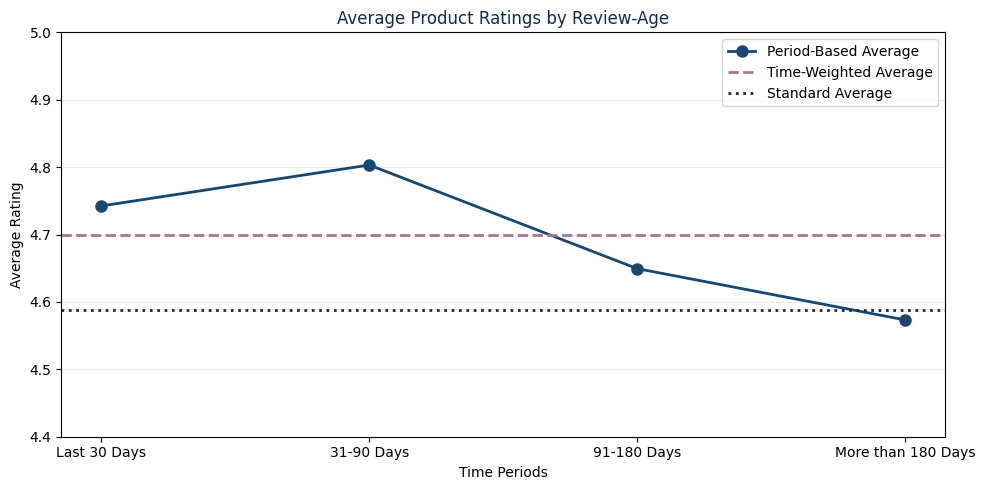

In [9]:
# Plot average ratings by review-age group
plt.figure(figsize=(10, 5))

plt.plot(
    time_periods_df["Time Period"],
    time_periods_df["Average Rating"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="#174871",
    label="Period-Based Average"
)

# Time-weighted average
plt.axhline(
    y=time_weighted_avg,
    color="#A77693",
    linestyle="--",
    linewidth=2,
    label="Time-Weighted Average"
)

# Standard average
plt.axhline(
    y=average_rating,
    color="#0F2D4D",
    linestyle=":",
    linewidth=2,
    label="Standard Average"
)

plt.xlabel("Time Periods")
plt.ylabel("Average Rating")
plt.title("Average Product Ratings by Review-Age", color="#0F2D4D")
plt.legend()

# Zoomed axis to highlight small differences
plt.ylim(4.4, 5)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
In this section, we rank reviews using the Wilson Lower Bound,
which accounts for both the proportion of helpful votes and
the uncertainty associated with the number of votes.
We then select the top 20 reviews as candidates for display
on the product page.
</p>

In [10]:
df["helpful_no"] = df["total_vote"] - df["helpful_yes"]

In [11]:
df[df["helpful_no"] < 0]

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote,helpful_no


In [12]:
df["score_pos_neg_diff"] = df["helpful_yes"]- df["helpful_no"]

In [13]:
def score_average_rating(up, down):
    if up + down == 0:
        return 0
    return up / (up + down)

df["score_average_rating"] = df.apply(lambda x: score_average_rating(x['helpful_yes'], x['helpful_no']), axis=1)

In [14]:
# Wilson Lower Bound Calculation
def wilson_lower_bound(up, down, confidence=0.95):
    n = up + down
    if n == 0: return 0
    z = st.norm.ppf(1 - (1 - confidence)/2)
    phat = up/n
    return (phat + z*z/(2*n) - z*math.sqrt((phat*(1-phat)+z*z/(4*n))/n))/(1+z*z/n)

df['wilson_lower_bound'] = df.apply(lambda x: wilson_lower_bound(x['helpful_yes'], x['helpful_no']), axis=1)

In [15]:
# Sort by Wilson Lower Bound score
df_sorted = df.sort_values("wilson_lower_bound", ascending=False).head(20)

In [16]:
df_sorted[
    ["overall", "helpful_yes", "helpful_no", "wilson_lower_bound"]
]

,overall,helpful_yes,helpful_no,wilson_lower_bound
2031,5.00000,1952,68,0.95754
3449,5.00000,1428,77,0.93652
4212,1.00000,1568,126,0.91214
317,1.00000,422,73,0.81858
4672,5.00000,45,4,0.80811
1835,5.00000,60,8,0.78465
3981,5.00000,112,27,0.73214
3807,3.00000,22,3,0.70044
4306,5.00000,51,14,0.67033
4596,1.00000,82,27,0.66359


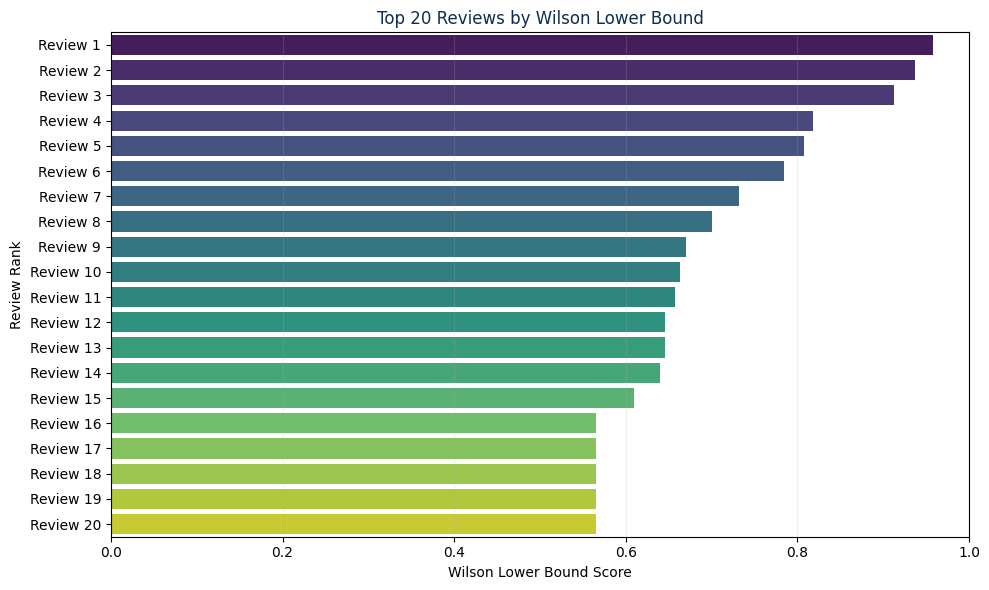

In [17]:
# Bar Chart: Top 20 Reviews by Wilson Lower Bound
df_sorted = df_sorted.copy()
df_sorted["review_label"] = [
    f"Review {i}" for i in range(1, len(df_sorted) + 1)
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_sorted,
    x="wilson_lower_bound",
    y="review_label",
    palette="viridis" ,
)

plt.xlabel("Wilson Lower Bound Score")
plt.ylabel("Review Rank")
plt.title("Top 20 Reviews by Wilson Lower Bound", color="#0F2D4D")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
Reviews with the highest Wilson Lower Bound scores appear at the top.
This ranking considers both the proportion of helpful votes and
the uncertainty associated with the number of votes.
</p>

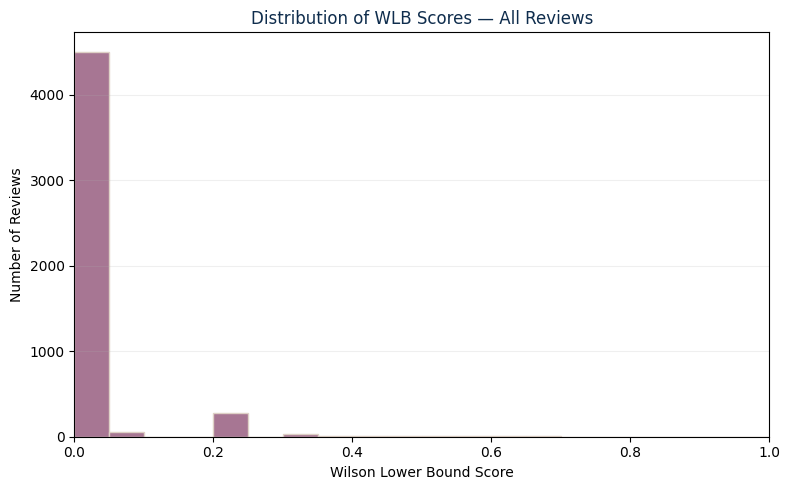

In [18]:
# Histogram: Distribution of WLB Scores — All Reviews
plt.figure(figsize=(8, 5))

plt.hist(
    df["wilson_lower_bound"],
    bins=20,
    range=(0, 1),
    color="#A77693",
    edgecolor="#DED1C6"
)

plt.xlabel("Wilson Lower Bound Score")
plt.ylabel("Number of Reviews")


plt.title("Distribution of WLB Scores — All Reviews", color="#0F2D4D")
plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
# Number of reviews with no votes
(df["total_vote"] == 0).sum()

4360

<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
While Wilson’s lower-bound scores are concentrated around zero, the number of comments with higher scores is decreasing. Low scores do not necessarily indicate that the comments are unreliable; they may be related to the absence of votes, a small number of votes, or a low percentage of upvotes.
</p>

<p style="color:#174871; font-size:16px; line-height:1.8; text-align:justify;">
In this study, the simple average was compared to the time-weighted product score, and the effect of the weight assigned to new reviews on the score
was examined. Subsequently, the reviews were ranked according to the Wilson
lower bound—which takes into account the helpful vote ratio
and the uncertainty arising from the number of votes—and the top 20 reviews were selected. This ranking does not prove the accuracy or reliability of the reviews; it provides a prioritization based on upvote data.
</p>
